# Logistic Regression Baseline

This notebook implements a Logistic Regression classifier as a baseline model for the credit card fraud detection task.

The model serves as a reference point for comparing more advanced machine learning and deep learning approaches later in the project.


## Data Preparation

The same cleaned dataset from the exploratory data analysis phase was used to ensure consistency across all models.

Data cleaning included:

- Removal of duplicate transactions
- Retention of all observations (no missing values were present)

Dataset after cleaning:

- Transactions: 283,726
- Fraudulent transactions: 473
- Fraud rate: 0.1667%

Dateset shape after cleaning: (283726, 31)
(283726, 30)
(283726,)
Training set:
Class
0    226602
1       378
Name: count, dtype: int64

Test set:
Class
0    56651
1       95
Name: count, dtype: int64

Training proportions:
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64

Test proportions:
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64
Best Threshold: 0.99
Best F1 Score: 0.718
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.66      0.79      0.72        95

    accuracy                           1.00     56746
   macro avg       0.83      0.89      0.86     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score: 0.9657


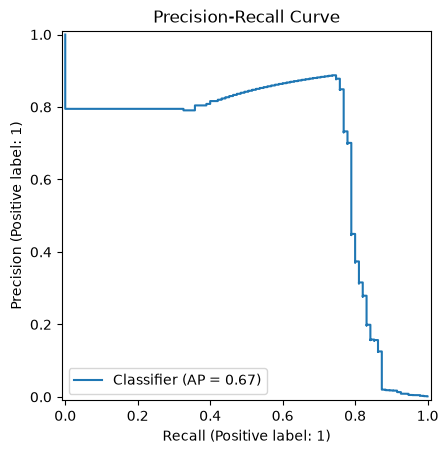

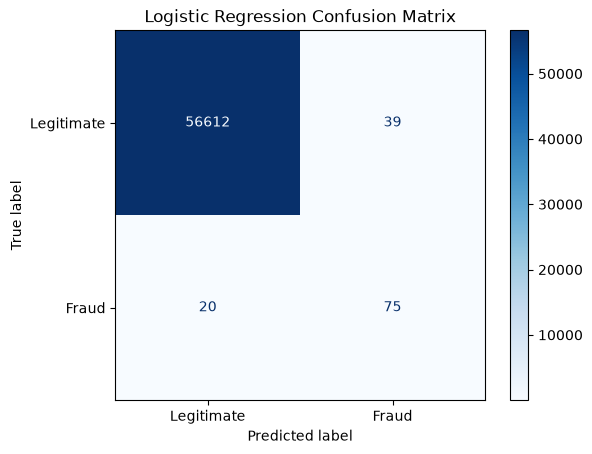

In [5]:
import kagglehub
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

#--------------
# Load Dataset
#--------------
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file = Path(path) / "creditcard.csv"
df = pd.read_csv(csv_file)

# Remove duplicate transactions
df = df.drop_duplicates()
print("Dateset shape after cleaning:", df.shape)
#df.head()

#--------------------
# Features und Target
#--------------------
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape)
print(y.shape)

#--------------------
# Train-Test-Split
#--------------------
stratify = y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Training set:")
print(y_train.value_counts())
print("\nTest set:")
print(y_test.value_counts())
print("\nTraining proportions:")
print(y_train.value_counts(normalize=True))
print("\nTest proportions:")
print(y_test.value_counts(normalize=True))

#--------------------
# Standardisierung
#--------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#--------------------
# Modell trainieren
#--------------------
class_weight = "balanced"

lr = LogisticRegression(class_weight = "balanced",
                        random_state = RANDOM_STATE, 
                        max_iter = 1000)
lr.fit(X_train_scaled, y_train)

#--------------------
# Vorhersagen
#--------------------
y_pred = lr.predict(X_test_scaled)
y_pred_proba = lr.predict_proba(X_test_scaled)[:,1]

best_threshold = 0
best_f1 = 0
for threshold in np.arange(0.1, 1.0, 0.01):
    y_pred_threshold=(y_pred_proba >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.3f}")

y_pred_best = (y_pred_proba >= best_threshold).astype(int)
#-----------------------
# Classification Report
#-----------------------
print(classification_report(y_test, y_pred_best))

#--------------------
# ROC-AUC
#--------------------
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

#------------------------
# Precision-Recall Curve
#------------------------
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba)
plt.title("Precision-Recall Curve")
plt.show()

#-----------------------
# Confusion Matrix
#-----------------------
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Legitimate", "Fraud"])
disp.plot(cmap = "Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


## Threshold Optimization

Because of the extreme class imbalance, the default classification threshold of 0.5 was not optimal.

A threshold search between 0.10 and 0.99 was performed to maximize the F1-score.

Best threshold:

- Threshold: 0.99
- F1-Score: 0.718

The optimized threshold significantly reduced false positive predictions while maintaining a high fraud detection rate.